<h1><center>🧠 Homework №1 — BERT for Aspect-Based Sentiment Classification

*Natural Language Processing Course, HSE 2026*

This homework is designed as a hands-on, research-style assignment. You
are expected not only to train models, but also to make methodological
decisions, justify them, and analyze results critically (*this will be taken into account when grading your assignment*) — like an ML
engineer or NLP researcher.

This homework **is based on the materials from the Webinar 2** - take a look at the notebook from that class as it might be really helpful when completing this assignment.

<p align="center">
  <img src="https://www.philschmid.de/static/blog/bert-text-classification-in-a-different-language/meme.png" width="60%">
</p>

### 📥 General Rules and Submission Guidelines

1. Copying code from external sources (**including using LLMs**) without explicit citation is strictly prohibited and will result in 0 points for the entire assignment. If you consult any resources or AI tools, you must clearly state this in a separate Markdown cell. If suspected of this, you might be asked to explain your code to the grader and answer their questions during a separate session to avoid the mentioned penalty.
2. All results must be fully **reproducible**. You are required to use `set_seed` everywhere so that the grader can obtain the same results when rerunning your notebook.
3. The notebook must run from top to bottom without errors. Submissions that fail to execute sequentially will not be accepted.
4. You must satisfy all requirements in each task to receive full credit. Partial completion may lead to partial scoring.
5. Do not modify the original notebook structure or provided Markdown cells. You are only allowed to write code in the sections marked `# TODO: your code here`. Any explanations, interpretations, or additional comments must be placed **in separate Markdown cells**. If you choose to do so, leave an explanation as to what and why was changed.
6. The final submission must be a completed `.ipynb` Jupyter Notebook. You may conduct your experiments in Jupyter Notebook, VS Code, or Google Colab — whichever environment you prefer.

### 🎯 Learning Objectives

By completing this homework, you will:
- Work with a realistic, noisy text dataset.
- Perform careful data preprocessing and label engineering.
- Fine-tune multiple encoder-based transformer models.
- Use validation loss for model selection (early stopping).
- Conduct basic hyperparameter tuning.
- Log your results.
- Build ablation tables and compare experimental settings.
- Interpret results obtained through conducted experiments.

Without any further ado, let's get started. Good luck, and may the odds be ever in your favor!

### 🔧 Environment Setup

Loading necessary libraries. If you need anything else, feel free to add more libraries and dependencies.

In [1]:
%%capture
! pip install transformers[torch] datasets evaluate optuna -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

from datasets import Dataset
import evaluate
import optuna
import random


from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [3]:
if not torch.cuda.is_available():
    print("Warning: training will be slow without GPU!")

In [4]:
def set_seed(seed):
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(1337)

### 🗂️ **Part №1. Data Preparation. ($1$ point)**

In this assignment, we're going to be work with the dataset containing reviews on restaurants. The dataset can be downloaded from [here](https://drive.google.com/file/d/19qXNsW-gc_H4ufAt0JREzszKzjKkh170/view).

In this part of the assignment, you will prepare the raw restaurant reviews dataset for model training. The goal is to obtain clean text data, a well-defined target variable, and reproducible train/validation/test splits.

**1.1. Loading and inspecting data ($0.25$ points)**

First, create a code cell that:
- loads the .jsonl file,
- prints basic statistics (size, columns, example rows),
- briefly comments on what you see.

In [5]:
!wget -O restaurants_reviews.jsonl \
"https://drive.google.com/uc?export=download&id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT"

--2026-02-19 06:56:05--  https://drive.google.com/uc?export=download&id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT
Resolving drive.google.com (drive.google.com)... 142.251.31.102, 142.251.31.113, 142.251.31.139, ...
Connecting to drive.google.com (drive.google.com)|142.251.31.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT&export=download [following]
--2026-02-19 06:56:05--  https://drive.usercontent.google.com/download?id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.69.132, 2a00:1450:4013:c04::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.69.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80131991 (76M) [application/octet-stream]
Saving to: ‘restaurants_reviews.jsonl’

restaurants_reviews 100%[===================>]  76.42

In [6]:
df = pd.read_json("restaurants_reviews.jsonl", lines=True)
df.head(3)

,review_id,general,food,interior,service,text
0,0,0,10,10,10,Вытянули меня сегодня в город и раз уж была в ...
1,1,0,9,10,9,проводили корпоратив на 60 чел. в этот - уже т...
2,2,0,9,10,10,Был в Гостях с женой один раз и еще раз с жено...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47139 entries, 0 to 47138
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review_id  47139 non-null  int64 
 1   general    47139 non-null  int64 
 2   food       47139 non-null  object
 3   interior   47139 non-null  object
 4   service    47139 non-null  object
 5   text       47139 non-null  object
dtypes: int64(2), object(4)
memory usage: 2.2+ MB


In [8]:
df.describe()

,review_id,general
count,47139.000000,47139.000000
mean,23569.000000,0.277732
std,13608.001506,1.100144
min,0.000000,0.000000
25%,11784.500000,0.000000
50%,23569.000000,0.000000
75%,35353.500000,0.000000
max,47138.000000,5.000000


### 47 139 отзывов это достаточно крупный корпус для обучения моделей. Все поля без пропусков. Датасет чистый, но есть проблема с типами признаков. ###

**1.2 Target variable selection and cleaning ($0.25$ points)**

#### 📚 Quick Dataset Overview

As you have probably already guessed, you will work with a dataset of Russian restaurant reviews stored in restaurants_reviews.jsonl. Each row corresponds to one user review and includes:

- review_id — unique identifier of the review  
- text — the review text (input to the model)  
- food — rating of food quality  
- service — rating of service quality  
- interior — rating of interior/atmosphere  
- general — overall rating (summary score)

The key idea is that the dataset provides aspect-based ratings: the same review can express different opinions about food, service, and interior. For example, a review might praise the food but criticize the service. This makes the task more realistic than standard “overall sentiment” classification.

Now, your task is to choose ONE aspect as the target variable for sentiment classification:

- ✅ food  
- ✅ service  
- ✅ interior  
- ❌ general cannot be used as a target label in this homework.

After that,
- Once you've picked your target - keep only 2 columns (target variable - name it "`food/interior/service_score`"  and `text`). You will not need id or other aspects (the ones you did NOT choose) for the training process, so we'll remove them for convenience.
- After selecting your target aspect, remove all samples where the corresponding rating equals $0$.  
In this dataset, a score of $0$ indicates that the reviewer **did not provide a rating for this aspect**, so such reviews should not be included in further analysis.
- Explain in a Markdown comment why the previous step is necessary (removal of $0$-scored reviews).

The result of this task is a df with 2 columns, e.g. "interior_score", "text" with no missing values.

In [9]:
df = df[["food", "text"]].rename(columns={"food": "food_score"})
df["food_score"] = pd.to_numeric(df["food_score"], errors="coerce")

df = df.dropna(subset=["food_score"])
df = df[df["food_score"] != 0]

df["food_score"] = df["food_score"].astype(int)
df = df.reset_index(drop=True)

In [10]:
df.head()

,food_score,text
0,10,Вытянули меня сегодня в город и раз уж была в ...
1,9,проводили корпоратив на 60 чел. в этот - уже т...
2,9,Был в Гостях с женой один раз и еще раз с жено...
3,7,В « Bel Canto » мы отмечали юбилей моего отца ...
4,10,"Здравствуйте , уважаемые женихи и невесты . Г..."


### Если оставить отзывы с нулевой оценкой, то модель будет обучаться на некорректных метках и может возникнуть сильный дисбаланс классов с доминированием нулей. Качество предсказаний и интерпретируемость результатов ухудшатся. ###

### Поэтому для корректного обучения необходимо исключить отзывы без фактической оценки и оставить только наблюдения с валидными значениями рейтинга (1–10). ###

**1.3 Label binning into 3 classes ($0.25$ points)**

At this point, you have a dataset that contains raw scores for your chosen aspect in the range 1–10 (after removing missing values).

Your goal in this section is to reduce this 10-point scale to three sentiment classes:

 - $0$ → BAD
 - $1$ → NEUTRAL
 - $2$ → GOOD

Before creating these classes, you must first visualize the original rating distribution so that your binning strategy is data-driven rather than arbitrary.
In the next cell, plot the distribution of the raw ratings using either:
 - a histogram, or
 - a bar/count plot.

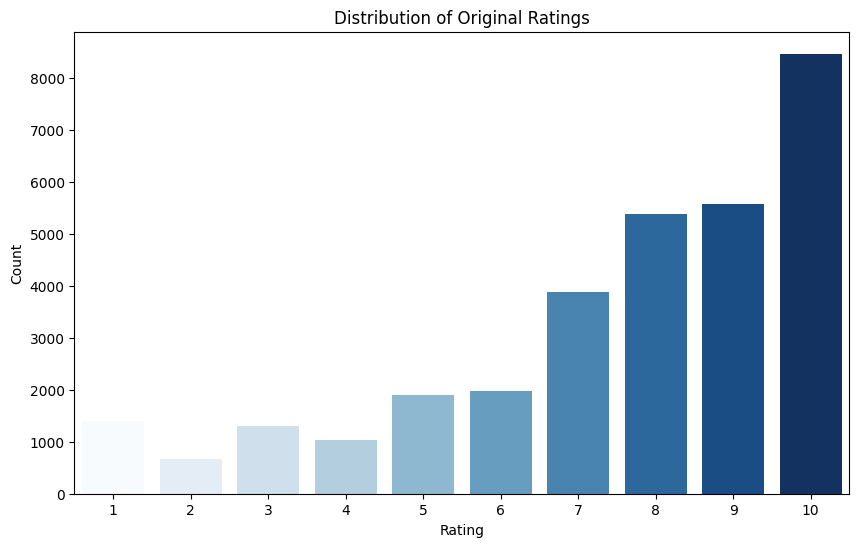

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="food_score", hue="food_score", order=sorted(df["food_score"].unique()), palette="Blues", legend=False)

plt.title("Distribution of Original Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

After inspecting the plot, add a Markdown explanation describing how and why you have decided to map the 1–10 scale into three groups.

**Your explanation here:**

### По распределению оценок видно, что низкие оценки 1-3 встречаются сравнительно редко и отражают явно негативный опыт. Средние оценки 4-6 образуют переходную зону без ярко выраженного позитива или негатива. Высокие оценки 7-10 составляют наибольшую долю наблюдений и соответствуют положительным отзывам. ###

### Такое разбиение соответствует семантике пользовательских рейтингов, учитывает реальное распределение данных, а не задаётся произвольно. ###

### Итоговое бинирование: ###

### 1-3 - 0 (Плохо) ###

### 4-6 - 1 (Нейтрально) ###

### 7-10 - 2 (Хорошо) ###

### Это обеспечивает логичную связь между числовыми рейтингами и категориальной оценкой настроения, необходимую для дальнейшего обучения модели. ###

Now, implement your mapping in code into three sentiment classes: BAD ($0$), NEUTRAL ($1$), and GOOD ($2$). Your mapping must produce labels in {$0$, $1$, $2$}.

In [ ]:
def bin_label(rating):
    if 1 <= rating <= 3:
        return 0
    elif 4 <= rating <= 6:
        return 1
    elif 7 <= rating <= 10:
        return 2
    else:
        return None

In [ ]:
df["label"] = df["food_score"].apply(bin_label)
df = df.dropna(subset=["label"])

df["label"] = df["label"].astype(int)

print("Распределение классов:")
print(df["label"].value_counts().sort_index())

print("\nПример преобразования:")
print(df.head())

Распределение классов:
label
0     3376
1     4916
2    23315
Name: count, dtype: int64

Пример преобразования:
   food_score                                               text  label
0          10  Вытянули меня сегодня в город и раз уж была в ...      2
1           9  проводили корпоратив на 60 чел. в этот - уже т...      2
2           9  Был в Гостях с женой один раз и еще раз с жено...      2
3           7  В « Bel Canto » мы отмечали юбилей моего отца ...      2
4          10  Здравствуйте , уважаемые женихи и невесты .  Г...      2


### Маппинг в метки классов произведен ###

**1.4. Formatting ($0.25$ points)**

At this point in the pipeline, we already have:
- a cleaned dataset of reviews, and
- their corresponding sentiment labels in {0, 1, 2}.

However, our data is still stored in a pandas DataFrame, which is not the native format expected by the Hugging Face training ecosystem.

**Task:** to make our data compatible with the Trainer API and other transformer utilities, you need to
- convert it into a datasets.Dataset object
- perform train/val/test split. The proprotions are 70/15/15

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [ ]:
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))

data = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

In [ ]:
data

DatasetDict({
    train: Dataset({
        features: ['food_score', 'text', 'label'],
        num_rows: 22124
    })
    validation: Dataset({
        features: ['food_score', 'text', 'label'],
        num_rows: 4741
    })
    test: Dataset({
        features: ['food_score', 'text', 'label'],
        num_rows: 4742
    })
})

### Произвел разбиение на train/val/test. При разбиении я использовал параметр stratify, посокольку он сохраняет распределение классов в train/val/test. ###

### 💻 **Transition Part ($1$ ⏩ $2$). From text to tensors. ($0.5$ points)**

Some theory for a better understanding of **why** (*but why?*... 🐧) we're doing **what** we're doing:

At this stage of the pipeline, we already have clean texts and well-defined labels in the right format, but transformer models cannot operate directly on raw strings. They require numerical representations that reflect how each specific model was trained. This is why we perform tokenization before training.

It is important to emphasize that tokenization is model-dependent. Different pretrained models were trained on different corpora and use different vocabularies, token boundaries, and subword segmentation rules. As a result, the same sentence may be split into different tokens by different models, even though the underlying meaning is identical. This is why we cannot tokenize the data once and reuse it for all models.

**In this assignment, the tokenization step must be repeated separately for each model.**

For each model separately, you will:
 1. Load the model-specific tokenizer from Hugging Face.
 2. Tokenize all three splits (train, val, test) of the Dataset object.
 3. Wrap the tokenized outputs and labels into a DataLoader, creating 3 separate dataloader objects.

Only after this step will you proceed to fine-tuning.


As our first model, let us take [ruBert-base](https://huggingface.co/sberbank-ai/ruBert-base/). Perform tokenization in the following cells.

In [ ]:
model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

data_tokenized = data.map(tokenize_fn, batched=True)

data_tokenized = data_tokenized.rename_column("label", "labels")

data_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/22124 [00:00<?, ? examples/s]

Map:   0%|          | 0/4741 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

Wrap the tokenized data into a DataLoader

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
data_tokenized

DatasetDict({
    train: Dataset({
        features: ['food_score', 'text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 22124
    })
    validation: Dataset({
        features: ['food_score', 'text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4741
    })
    test: Dataset({
        features: ['food_score', 'text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4742
    })
})

### Создал токенизатор. Токенизировал датасет. Создал даталоадер для Trainer API. ###

**What you enter Part 2 with:**

At the start of Part 2, you should have:
1. 3 Dataloader objects
2. All of them must be tokenized (you will later need to change it, depending on what model you are training),

### 💪 **Part 2. Fine-tuning. ($3$ points)**

In this part of the assignment, you will complete the following stages:
 1. **Baseline model.**
Train a baseline encoder model on the prepared dataset. This establishes a reference point for all future comparisons. ($1$ point)
 2. **Model comparison (3 encoders total).**
Train two additional encoder models under the same data split and evaluation protocol. Compare results across all three models and choose the most promising model to continue working with. ($2$ points)

Training must be stopped automatically via early stopping: once the quality metric stops improving (i.e., reaches a plateau), training should terminate and the best checkpoint must be selected. Do not forget that data is shared across all models (do not redo the split), but **tokenization is model-specific**.

#### Models to choose from:
1. [ruBert-base](https://huggingface.co/sberbank-ai/ruBert-base/)  
2. [ruBert-large](https://huggingface.co/sberbank-ai/ruBert-large/)
3. [ruBert-tiny](https://huggingface.co/cointegrated/rubert-tiny2)
4. [mBert](https://huggingface.co/google-bert/bert-base-multilingual-cased)

More documentation: [`transformers`](https://huggingface.co/docs/transformers/index)


Throughout this assignment, the primary metric is `accuracy` (multiclass classification).
Before training any model, you must implement a function that computes accuracy from model predictions. In the next section, you will define this metric function and integrate it into your training loop.

In [ ]:
def compute_metrics(eval_pred):
    """ Func for calculating accuracy
    (The primary metric must be accuracy. You may optionally add others) """

    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, preds)

    return { "accuracy" : float(accuracy) }

Next, choose a model (overall you need to conduct initial experiments with 3 of them). In the initial task, we already used a tokenizer for ruBert-base, so you might want to proceed with that first.

In [ ]:
model_name = "DeepPavlov/rubert-base-cased"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)


pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

Thanks to a user-friendly interface of training, a developer can focus on high-level tasks (rather than implementing a train loop):

Modify `Trainer` ([documentation here](https://huggingface.co/docs/transformers/en/main_classes/trainer#trainer)) and `TrainingArguments`([documentation here](https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments)) and complete the following code cells.


Do not forget to add `load_best_model_at_end=True`, `metric_for_best_model=...`, `greater_is_better=True` as well as `evaluation_strategy=...`

Use `EarlyStoppingCallback` to ensure training is stopped once the metric used for evaluation stops increasing over an established number of epochs.

In [ ]:
args_es = TrainingArguments(
    output_dir="./bert_es",
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",      
    save_strategy="epoch",            
    logging_strategy="steps",

    load_best_model_at_end=True,
    metric_for_best_model="accuracy", 
    greater_is_better=True,

    run_name="ruBERT-base-early_stopping",
    logging_steps=10,
    save_total_limit=2,
    report_to="none"                 
)

In [ ]:
trainer = Trainer(
    model=model,
    args=args_es,
    train_dataset=data_tokenized["train"],
    eval_dataset=data_tokenized["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


In [ ]:
trainer.train()

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy
1,0.597020,0.507717,0.787808
2,0.504447,0.541030,0.801308
3,0.328245,0.618359,0.790972
4,0.203060,0.723467,0.760388


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2768, training_loss=0.38026541428414384, metrics={'train_runtime': 4693.7399, 'train_samples_per_second': 47.135, 'train_steps_per_second': 1.474, 'total_flos': 1.1642242507628544e+16, 'train_loss': 0.38026541428414384, 'epoch': 4.0})

In [ ]:
results = []

In [ ]:
results.append({
        "model": "ruBert-base",
        "learning_rate": args_es.learning_rate,
        "batch_size": args_es.per_device_train_batch_size,
        "epochs_trained": trainer.state.epoch,
        "best_val_accuracy": trainer.state.best_metric,
    })

### Произвел расчет. Сохранил результаты. ###

Do this for 3 different encoders (choose them from what was offered previously).

### Возьмем для сравнения модели Bert-tiny и mBert. ###

In [ ]:
model_name = "cointegrated/rubert-tiny"

tiny_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

data_tokenized = data.map(tokenize_fn, batched=True)

data_tokenized = data_tokenized.rename_column("label", "labels")

data_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider train

Map:   0%|          | 0/22124 [00:00<?, ? examples/s]

Map:   0%|          | 0/4741 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

In [ ]:
args_es = TrainingArguments(
    output_dir="./bert_tiny",
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",      
    save_strategy="epoch",            
    logging_strategy="steps",

    load_best_model_at_end=True,
    metric_for_best_model="accuracy", 
    greater_is_better=True,

    run_name="ruBERT-tiny-early_stopping",
    logging_steps=10,
    save_total_limit=2,
    report_to="none"            
)

In [ ]:
trainer = Trainer(
    model=tiny_model,
    args=args_es,
    train_dataset=data_tokenized["train"],
    eval_dataset=data_tokenized["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.619145,0.594961,0.767981
2,0.577761,0.559351,0.770513
3,0.471070,0.576659,0.773887
4,0.481455,0.591359,0.769247
5,0.473734,0.627041,0.748787


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

TrainOutput(global_step=3460, training_loss=0.5062737712970359, metrics={'train_runtime': 325.8439, 'train_samples_per_second': 678.975, 'train_steps_per_second': 21.237, 'total_flos': 407920570398720.0, 'train_loss': 0.5062737712970359, 'epoch': 5.0})

In [ ]:
results.append({
        "model": "ruBert-tiny",
        "learning_rate": args_es.learning_rate,
        "batch_size": args_es.per_device_train_batch_size,
        "epochs_trained": trainer.state.epoch,
        "best_val_accuracy": trainer.state.best_metric,
    })

In [ ]:
model_name = "google-bert/bert-base-multilingual-cased"

large_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

data_tokenized = data.map(tokenize_fn, batched=True)

data_tokenized = data_tokenized.rename_column("label", "labels")

data_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/22124 [00:00<?, ? examples/s]

Map:   0%|          | 0/4741 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

In [ ]:
args_es = TrainingArguments(
    output_dir="./mbert",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",      
    save_strategy="epoch",            
    logging_strategy="steps",

    load_best_model_at_end=True,
    metric_for_best_model="accuracy", 
    greater_is_better=True,

    run_name="mBERT-early_stopping",
    logging_steps=10,
    save_total_limit=2,
    report_to="none"                  
)

In [ ]:
trainer = Trainer(
    model=large_model,
    args=args_es,
    train_dataset=data_tokenized["train"],
    eval_dataset=data_tokenized["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.784423,0.768296,0.737608
2,0.905388,0.759695,0.737608
3,0.706051,0.753500,0.737608


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=4149, training_loss=0.7536548891249092, metrics={'train_runtime': 3547.4105, 'train_samples_per_second': 62.367, 'train_steps_per_second': 3.899, 'total_flos': 8731681880721408.0, 'train_loss': 0.7536548891249092, 'epoch': 3.0})

In [ ]:
results.append({
        "model": "mBert",
        "learning_rate": args_es.learning_rate,
        "batch_size": args_es.per_device_train_batch_size,
        "epochs_trained": trainer.state.epoch,
        "best_val_accuracy": trainer.state.best_metric,
    })

Now, before proceedings to hyperparamter tuning, you must compare the three pretrained encoders you trained under the **same** data split and evaluation protocol. Create an ablation table and report:
1. Model name
2. Key hyperparameter values (they must be the same for all models for the results to be comparable)
3. Number of epochs you ran
4. Best validation accuracy

In [ ]:
results_df = pd.DataFrame(results).sort_values(
    by="best_val_accuracy",
    ascending=False
)

results_df["best_val_accuracy"] = results_df["best_val_accuracy"].round(3)
results_df["epochs_trained"] = results_df["epochs_trained"].astype(int)

results_df

,model,learning_rate,batch_size,epochs_trained,best_val_accuracy
0,ruBert-base,0.00005,32,4,0.801
1,ruBert-tiny,0.00005,32,5,0.774
2,mBert,0.00005,16,3,0.738


After completing the table, select a model for further hyperparameter tuning and explain your choice. Zero analysis and/or explanation will result in zero points.

**Your answer here:** 

### В ходе сравнительного эксперимента трёх предобученных кодеров (ruBert-tiny, ruBert-base, mBERT), обученных при одинаковом протоколе оценки и разбиении данных, наилучший результат показала модель ruBert-base с валидационной точностью 0.801.

### Модель ruBert-tiny уступает по качеству вследствие меньшей параметрической мощности, а мультиязычная mBERT демонстрирует худшую производительность из-за отсутствия языковой специализации.

### В связи с этим для дальнейшей настройки гиперпараметров выбрана модель ruBert-base как обеспечивающая оптимальный баланс качества и вычислительной эффективности.


#### 🔧 **Part 3. Hyperparameter tuning ($3$ points)**

In this part you will perform the following:

 1. **Hyperparameter tuning** (selected model only).
After choosing the best-performing model from Part 2, perform hyperparameter tuning on `train` and `val` portions of the dataset (not on test!!!). You may do this manually or using Optuna. Your goal is to improve validation performance while keeping the experiment design fair and reproducible ($2$ points).
 2. **Final evaluation.**
Take the best checkpoint from your tuned setup and report the final model quality on the held-out `test` set. The test set must not be used for training decisions ($1$ point).

As stated earlier, you can either perform hyperparameter tuning manually  or you can use `Optuna`. The `Trainer` API includes built-in integration with `Optuna`, which is a tool for hyperparameter optimization in machine learning.

The list of hyperparameters you may want to choose from:
1. Learning rate
2. Batch size
3. Max sequence length
4. Weight decay
5. Warmup ratio
6. Type of scheduler

Your task is to implement a search over at least $2$ different hyperparameters.
A detailed tutorial can be found [here](https://huggingface.co/docs/transformers/hpo_train).

It is important to keep in mind that hyperparameter search should be performed on a small subset of the training data, and evaluation metrics should be computed on a small subset of the validation data.

In [ ]:
model_name = "DeepPavlov/rubert-base-cased"

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

data_tokenized = data.map(tokenize_fn, batched=True)

data_tokenized = data_tokenized.rename_column("label", "labels")

data_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

train_frac = 0.10  
val_frac   = 0.20  

small_train = data_tokenized["train"].shuffle().select(
    range(int(len(data_tokenized["train"]) * train_frac))
)
small_val = data_tokenized["validation"].shuffle().select(
    range(int(len(data_tokenized["validation"]) * val_frac))
)

small_data = DatasetDict({"train": small_train, "validation": small_val})
len(small_data["train"]), len(small_data["validation"])


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

Map:   0%|          | 0/22124 [00:00<?, ? examples/s]

Map:   0%|          | 0/4741 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

(2212, 948)

To take a look and access the best hyperparamters, you can refer to the corresponding attribute:

In [ ]:
def objective(trial):

    model = AutoModelForSequenceClassification.from_pretrained(
        "DeepPavlov/rubert-base-cased",
        num_labels=3
    )

    args = TrainingArguments(
        output_dir=f"./optuna_trial_{trial.number}",
        num_train_epochs=3,

        learning_rate=trial.suggest_float("learning_rate", 1e-5, 8e-5, log=True),
        weight_decay=trial.suggest_float("weight_decay", 0.0, 0.2),

        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,

        eval_strategy="epoch",
        save_strategy="no",

        logging_steps=50,
        report_to="none",
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=small_data["train"],
        eval_dataset=small_data["validation"],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
    )

    trainer.train()

    metrics = trainer.evaluate()
    return metrics["eval_accuracy"]


Now, train your selected model with these values of hyperparameters on a full dataset and evaluate its final quality on test data.

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

study.best_params, study.best_value


[I 2026-02-18 15:23:46,023] A new study created in memory with name: no-name-1cad580f-9d6b-4dc0-b696-a7a7a60aaae8


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

Epoch,Training Loss,Validation Loss,Accuracy
1,0.653437,0.526467,0.797468
2,0.499666,0.529948,0.776371
3,0.348749,0.564493,0.794304


[I 2026-02-18 15:29:34,315] Trial 0 finished with value: 0.7943037974683544 and parameters: {'learning_rate': 2.9230493235593197e-05, 'weight_decay': 0.17024563636662393}. Best is trial 0 with value: 0.7943037974683544.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

Epoch,Training Loss,Validation Loss,Accuracy
1,0.731618,0.660144,0.765823
2,0.586016,0.579020,0.727848
3,0.462574,0.569256,0.794304


[I 2026-02-18 16:21:43,856] Trial 9 finished with value: 0.7943037974683544 and parameters: {'learning_rate': 4.580965501868039e-05, 'weight_decay': 0.11218999853847766}. Best is trial 5 with value: 0.7953586497890295.


({'learning_rate': 3.13765085745794e-05, 'weight_decay': 0.15766194978304943},
 0.7953586497890295)

In [ ]:
best_params = study.best_params
best_score = study.best_value

best_params, best_score

({'learning_rate': 3.13765085745794e-05, 'weight_decay': 0.15766194978304943},
 0.7953586497890295)

Create a table with the final results of the training process and comment on what results you have obtained.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_final = Trainer(
    model=AutoModelForSequenceClassification.from_pretrained(
        "DeepPavlov/rubert-base-cased",
        num_labels=3
    ),
    args=TrainingArguments(
        output_dir="./final_model",
        num_train_epochs=5,

        learning_rate=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"],

        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,

        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
    ),
    train_dataset=data_tokenized["train"],
    eval_dataset=data_tokenized["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

trainer_final.train()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

Epoch,Training Loss,Validation Loss,Accuracy
1,0.550350,0.519962,0.775786
2,0.418902,0.510037,0.792027
3,0.297362,0.625626,0.797511
4,0.190731,0.897532,0.785277
5,0.120795,1.099978,0.780637


TrainOutput(global_step=6915, training_loss=0.3186054795183139, metrics={'train_runtime': 5235.6077, 'train_samples_per_second': 21.128, 'train_steps_per_second': 1.321, 'total_flos': 1.4550722894076768e+16, 'train_loss': 0.3186054795183139, 'epoch': 5.0})

In [ ]:
final_test_metrics = trainer_final.evaluate(data_tokenized["test"])

test_acc = final_test_metrics["eval_accuracy"]

final_table = pd.DataFrame([{
    "model": "ruBERT-base",
    "learning_rate": best_params["learning_rate"],
    "weight_decay": best_params["weight_decay"],
    "best_val_accuracy": best_score,
    "test_accuracy": test_acc,
}])

final_table

,model,learning_rate,weight_decay,best_val_accuracy,test_accuracy
0,ruBERT-base,0.000031,0.157662,0.795359,0.788697


**Your comments here:**

### HPO делали на подвыборках train/val ( 10% / 20% ) чтобы ускорить поиск.

### Подобрали 2 гиперпараметра: learning_rate, weight_decay.

#### 😎 **Part 4. Final Experiments and Analysis ($2.5$ points)**

**4.1. Layer Freezing Experiment ($1.25$ points)**
Choose one of the four pretrained models from earlier.
You must:
 1. Freeze all encoder layers except the last transformer block and the classification head.
 2. Train the model on the prepared data.
 3. Report test accuracy for the best checkpoint.
 4. Analyse your results and comment on them in a separate md cell. No analysis or/and comments on your results will result in 0 points for this task.

(*See example in the notebook from the BERT webinar*)

In [ ]:
model_name = "DeepPavlov/rubert-base-cased"

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

data_tokenized = data.map(tokenize_fn, batched=True)

data_tokenized = data_tokenized.rename_column("label", "labels")

data_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

for param in model.bert.parameters():
    param.requires_grad = False

for param in model.bert.encoder.layer[-1].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

args_freeze = TrainingArguments(
    output_dir="./rubert_base_frozen",
    num_train_epochs=8,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=3e-5,         
    weight_decay=0.15,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    logging_steps=20,
    save_total_limit=2,
    report_to="none",
)

trainer_freeze = Trainer(
    model=model,
    args=args_freeze,
    train_dataset=data_tokenized["train"],
    eval_dataset=data_tokenized["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    data_collator=data_collator
)

trainer_freeze.train()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

Map:   0%|          | 0/22124 [00:00<?, ? examples/s]

Map:   0%|          | 0/4741 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=5536, training_loss=0.5217083153352572, metrics={'train_runtime': 3471.5291, 'train_samples_per_second': 50.984, 'train_steps_per_second': 1.595, 'total_flos': 2.328448501525709e+16, 'train_loss': 0.5217083153352572, 'epoch': 8.0})

In [ ]:
test_metrics = trainer_freeze.evaluate(data_tokenized["test"])
test_metrics


{'eval_loss': 0.4939565658569336,
 'eval_accuracy': 0.7950231969633066,
 'eval_runtime': 61.4532,
 'eval_samples_per_second': 77.164,
 'eval_steps_per_second': 2.425,
 'epoch': 8.0}

In [ ]:
test_accuracy = test_metrics["eval_accuracy"]
test_accuracy

0.7950231969633066

**Your comments here:**

### В данном эксперименте была использована модель ruBert-base, в которой были заморожены все слои кодера, кроме последнего блока трансформера и классифицирующей головы.

### Такой подход позволяет:
### - существенно сократить число обучаемых параметров;
### - ускорить обучение.

### После обучения лучшая контрольная точка показала test accuracy = 0.7950.

### По сравнению с полным fine-tuning качество модели немного ниже, поскольку большая часть модели остаётся неизменной


**4.2. Return to the original 10-class problem ($1.25$ points)**

Take the best model configuration from Part 3 (after tuning).

You must:
 1. Rebuild the dataset for the same selected aspect as in Part 1, but now use its original raw ratings ($1$–$10$) as labels.  
   That is, keep **the same target aspect**, but omit the BAD/NEUTRAL/GOOD binning step into $3$ classes ($0$, $1$, $2$) and treat each distinct rating as its own class.
 2. If the train set is imbalanced, apply a balancing method.
 3. Fine-tune the model again.
 4. Evaluate the final checkpoint on the test set and report accuracy.
 5. Analyse your results and comment on them in a separate md cell. No analysis or/and comments on your results will result in 0 points for this task.


In [11]:
df10 = df[["food_score", "text"]].copy()

df10["label"] = df10["food_score"] - 1

df10 = df10[["label", "text"]].reset_index(drop=True)

df10.head(), df10["label"].min(), df10["label"].max()


(   label                                               text
 0      9  Вытянули меня сегодня в город и раз уж была в ...
 1      8  проводили корпоратив на 60 чел. в этот - уже т...
 2      8  Был в Гостях с женой один раз и еще раз с жено...
 3      6  В « Bel Canto » мы отмечали юбилей моего отца ...
 4      9  Здравствуйте , уважаемые женихи и невесты .  Г...,
 0,
 9)

In [12]:
train_df, temp_df = train_test_split(
    df10,
    test_size=0.30,
    stratify=df10["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

data10 = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
})

{split: len(data10[split]) for split in data10}

{'train': 22124, 'validation': 4741, 'test': 4742}

In [13]:
from sklearn.utils.class_weight import compute_class_weight

y_train = np.array(data10["train"]["label"])
classes = np.arange(10)

class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)

class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([2.2645, 4.6873, 2.4206, 3.0348, 1.6723, 1.5928, 0.8128, 0.5875, 0.5667,
        0.3732])

In [14]:
model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

data10_tok = data10.map(tokenize_fn, batched=True)

data10_tok = data10_tok.rename_column("label", "labels")

cols = ["input_ids", "attention_mask", "labels"]
if "token_type_ids" in data10_tok["train"].column_names:
    cols.insert(2, "token_type_ids")

data10_tok.set_format(type="torch", columns=cols)

data10_tok


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/22124 [00:00<?, ? examples/s]

Map:   0%|          | 0/4741 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 22124
    })
    validation: Dataset({
        features: ['labels', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4741
    })
    test: Dataset({
        features: ['labels', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4742
    })
})

In [15]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
    ):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        w = self.class_weights.to(logits.device)
        loss_fct = nn.CrossEntropyLoss(weight=w)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [17]:
def compute_metrics_10(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": float(acc)
    }


In [18]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=10)

args10 = TrainingArguments(
    output_dir="./rubert_base_10class",
    num_train_epochs=8,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    logging_steps=20,
    save_total_limit=2,
    report_to="none",
)

trainer10 = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=args10,
    train_dataset=data10_tok["train"],
    eval_dataset=data10_tok["validation"],
    compute_metrics=compute_metrics_10,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    data_collator=data_collator
)

trainer10.train()

test_metrics_10 = trainer10.evaluate(data10_tok["test"])
test_metrics_10


pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

Epoch,Training Loss,Validation Loss,Accuracy
1,1.958288,1.925378,0.374183
2,1.797430,1.893130,0.346973
3,1.572550,2.071848,0.368699


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 1.9319186210632324,
 'eval_accuracy': 0.35955293125263604,
 'eval_runtime': 64.9207,
 'eval_samples_per_second': 73.043,
 'eval_steps_per_second': 2.295,
 'epoch': 3.0}

In [19]:
test_metrics_10["eval_accuracy"]


0.35955293125263604

**Your comments here:**

### В этом эксперименте целевая переменная была изменена: вместо трёх классов тональности (BAD/NEUTRAL/GOOD) модель предсказывает исходный рейтинг аспекта (1–10), где каждый рейтинг — отдельный класс. ###

### Распределение рейтингов оказалось несбалансированным (часть оценок встречается существенно чаще), поэтому была применена балансировка через веса классов в функции потерь (weighted cross-entropy), рассчитанные по обучающей выборке. Это позволяет увеличить вклад редких классов в градиент и уменьшить склонность модели предсказывать только частые оценки. ###

### В 10-классовой постановке точность модели составила около 0.36, что значительно ниже результатов 3-классовой классификации. Это ожидаемо, поскольку задача предсказания точного рейтинга существенно сложнее и требуется различать близкие по смыслу оценок. ###

### Тем не менее полученная точность существенно превышает случайный baseline (0.10), что свидетельствует о способности модели извлекать полезные признаки из текста. ###

In [22]:
from sklearn.metrics import classification_report

preds = trainer10.predict(data10_tok["test"])
y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.36      0.55      0.43       209
           1       0.00      0.00      0.00       101
           2       0.15      0.24      0.19       196
           3       0.20      0.01      0.01       156
           4       0.14      0.10      0.11       284
           5       0.20      0.28      0.24       297
           6       0.24      0.28      0.26       584
           7       0.28      0.22      0.25       807
           8       0.28      0.09      0.14       837
           9       0.53      0.80      0.64      1271

    accuracy                           0.36      4742
   macro avg       0.24      0.26      0.23      4742
weighted avg       0.32      0.36      0.32      4742



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Показатель macro-f1 остается относительно низким (0.23), главным образом из-за сильного дисбаланса классов. Модель склонна предсказывать высокие рейтинги (особенно класс 9), которые доминируют в наборе данных, в то время как редкие классы с низким рейтингом распознаются плохо. ###

### Такое поведение ожидаемо для задач тонкого предсказания рейтинга, поскольку различать соседние оценки (например, между 7, 8 и 9) значительно сложнее, чем в грубой трехклассовой классификации. ###